# Notebook 2 — Methodological Innovation (ML, Modelling, Control)

**Reviewer concern:** *Limited scientific novelty — primarily system integration; lacks advanced control, ML decision-making, and formal system modelling.*

**Reference:** Karimzadeh et al. (2025) FDD workflow: fault formulation → ML classifiers (RF, SVM, ANN, LSTM) → diagnosis.

**Hardware note:** TDS = $f(EC)$ on one probe — state-space and ML use **EC + waterTemp + EMS + LMS** only.

**Our extensions:**
1. **Formal fault models** (Table 1) on real EC traces
2. **FDD** with independent environmental context (EMS/LMS/pumps)
3. **State-space** $[EC, T_{solution}]$ — no derived TDS state
4. **ML dosing policy** from independent sensors + EC
5. **Predictive control** preview using non-derived features

**Outputs:** `results/innovation_metrics.csv`, figures in `figures/innovation/`


## Step 1 — Setup


In [11]:
# pip install -r requirements.txt
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

try:
    from IPython.display import display
except ImportError:
    display = print

DATA_DIR = Path('.')
FIG_DIR = DATA_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
INN_DIR = FIG_DIR / 'innovation'; INN_DIR.mkdir(parents=True, exist_ok=True)
(DATA_DIR/'results').mkdir(exist_ok=True)
def regression_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return dict(RMSE=float(np.sqrt(mean_squared_error(y_true, y_pred))),
                MAE=float(mean_absolute_error(y_true, y_pred)),
                R2=float(r2_score(y_true, y_pred)), n=len(y_true))

def bootstrap_ci(y_true, y_pred, n_boot=500):
    rng = np.random.default_rng(RANDOM_STATE)
    n = len(y_true); rmse_s, mae_s, r2_s = [], [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        m = regression_metrics(np.asarray(y_true)[idx], np.asarray(y_pred)[idx])
        rmse_s.append(m['RMSE']); mae_s.append(m['MAE']); r2_s.append(m['R2'])
    return {k: np.quantile(v, [0.025, 0.975]) for k, v in
            zip(['RMSE','MAE','R2'], [rmse_s, mae_s, r2_s])}

def cv_metrics_ts(X, y, model, n_splits=5):
    """Time-series CV: return per-fold metrics + mean/std for error bars (like Fig. 8 paper)."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    folds = []
    for tr, te in tscv.split(X):
        m = model.__class__(**model.get_params())
        m.fit(X.iloc[tr], y.iloc[tr])
        pred = m.predict(X.iloc[te])
        folds.append(regression_metrics(y.iloc[te], pred))
    df = pd.DataFrame(folds)
    summary = df.mean().to_dict()
    summary.update({f'{k}_std': df[k].std() for k in ['RMSE','MAE','R2']})
    return df, summary
def load_nfads():
    cols = ['ec','tds','ph','waterTemp','createdAt','peristalticPumpA','peristalticPumpB',
            'peristalticPumpPhup','peristalticPumpPhdown']
    chunks = [c for c in pd.read_csv(DATA_DIR/'test.nfads.csv', usecols=cols, chunksize=50_000)]
    df = pd.concat(chunks, ignore_index=True)
    df['createdAt'] = pd.to_datetime(df['createdAt'], utc=True)
    for c in ['ec','tds','ph','waterTemp']: df[c] = pd.to_numeric(df[c], errors='coerce')
    for c in ['peristalticPumpA','peristalticPumpB','peristalticPumpPhup','peristalticPumpPhdown']:
        df[c] = df[c].astype(str).str.lower().eq('true')
    df['pump_any'] = df[['peristalticPumpA','peristalticPumpB','peristalticPumpPhup','peristalticPumpPhdown']].any(axis=1)
    return df.sort_values('createdAt')

def load_ems():
    cols = ['dht22Temp','dht22Moisture','oxygen','pressure','createdAt']
    df = pd.read_csv(DATA_DIR/'test.ems.csv', usecols=cols)
    df['createdAt'] = pd.to_datetime(df['createdAt'], utc=True)
    for c in ['dht22Temp','dht22Moisture','oxygen','pressure']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    return df.sort_values('createdAt')

def load_lms():
    cols = ['bh1750','ldr','tsl2591','createdAt']
    df = pd.read_csv(DATA_DIR/'test.lms.csv', usecols=cols)
    df['createdAt'] = pd.to_datetime(df['createdAt'], utc=True)
    for c in ['bh1750','ldr','tsl2591']: df[c] = pd.to_numeric(df[c], errors='coerce')
    return df.sort_values('createdAt')

def merge_hourly(nf, ems, lms):
    nf = nf[(nf.ec.between(0,3500)) & (nf.tds.between(0,2500)) & (nf.waterTemp.between(0,45))].copy()
    nf['hour'] = nf.createdAt.dt.floor('h')
    ems_ok = ems[ems.dht22Temp.between(0,60) & ems.dht22Moisture.between(0,100)].copy()
    ems_ok['hour'] = ems_ok.createdAt.dt.floor('h')
    lms['hour'] = lms.createdAt.dt.floor('h')
    h_nf = nf.groupby('hour').agg(
        ec=('ec','median'), tds=('tds','median'),  # tds kept only for formula audit
        waterTemp=('waterTemp','median'),
        pump_duty=('pump_any','mean'),
        pump_phup=('peristalticPumpPhup','mean'),
        pump_nutrient=('peristalticPumpA','mean'),
    ).reset_index()
    h_ems = ems_ok.groupby('hour').agg(
        air_temp=('dht22Temp','median'), humidity=('dht22Moisture','median'),
        oxygen=('oxygen','median'), pressure=('pressure','median'),
    ).reset_index()
    h_lms = lms.groupby('hour').agg(
        light_bh1750=('bh1750','median'), light_ldr=('ldr','median'),
        light_tsl=('tsl2591','median'),
    ).reset_index()
    m = pd.merge(h_nf, h_ems, on='hour', how='inner')
    m = pd.merge(m, h_lms, on='hour', how='left')  # LMS sparse — OK
    for c in ['light_bh1750','light_ldr','light_tsl']:
        m[c] = m[c].fillna(m[c].median())
    return m.sort_values('hour').reset_index(drop=True)

# Independent sensors only (for ML features — never use derived TDS to predict EC)
INDEPENDENT_FEATURES = [
    'air_temp', 'humidity', 'oxygen', 'pressure',
    'waterTemp', 'pump_duty', 'pump_phup', 'pump_nutrient',
    'light_bh1750', 'light_ldr', 'light_tsl',
]

sensor_map = pd.DataFrame([
    ['EC', 'NFADS', 'Conductivity probe', 'Independent', 'Target for virtual sensor'],
    ['TDS', 'NFADS', 'Derived', 'NO — TDS = f(EC) firmware', 'Audit formula only'],
    ['waterTemp', 'NFADS', 'DS18B20', 'Independent', 'Feature + validation target'],
    ['pump_*', 'NFADS', 'Actuators', 'Independent', 'Control inputs'],
    ['air_temp', 'EMS', 'DHT22', 'Independent', 'Feature'],
    ['humidity', 'EMS', 'DHT22', 'Independent', 'Feature'],
    ['oxygen', 'EMS', 'O2 sensor', 'Independent', 'Feature'],
    ['pressure', 'EMS', 'Barometric', 'Independent', 'Feature'],
    ['light_*', 'LMS', 'BH1750/LDR/TSL', 'Independent', 'Feature (when logged)'],
    ['pH', 'NFADS', 'pH probe', 'Independent (when working)', 'Future — currently sparse'],
], columns=['Signal','Subsystem','Hardware','Use in ML','Role'])

nf_raw = load_nfads()
ems_raw = load_ems()
lms_raw = load_lms()
hourly = merge_hourly(nf_raw, ems_raw, lms_raw)
print(f'Hourly merged records: {len(hourly)}')
display(sensor_map)
display(hourly[INDEPENDENT_FEATURES + ['ec','tds']].describe().round(2))


Hourly merged records: 294


,Signal,Subsystem,Hardware,Use in ML,Role
0,EC,NFADS,Conductivity probe,Independent,Target for virtual sensor
1,TDS,NFADS,Derived,NO — TDS = f(EC) firmware,Audit formula only
2,waterTemp,NFADS,DS18B20,Independent,Feature + validation target
3,pump_*,NFADS,Actuators,Independent,Control inputs
4,air_temp,EMS,DHT22,Independent,Feature
5,humidity,EMS,DHT22,Independent,Feature
6,oxygen,EMS,O2 sensor,Independent,Feature
7,pressure,EMS,Barometric,Independent,Feature
8,light_*,LMS,BH1750/LDR/TSL,Independent,Feature (when logged)
9,pH,NFADS,pH probe,Independent (when working),Future — currently sparse


,air_temp,humidity,oxygen,pressure,waterTemp,pump_duty,pump_phup,pump_nutrient,light_bh1750,light_ldr,light_tsl,ec,tds
count,294.00,294.00,294.00,294.00,294.00,294.00,294.00,294.00,294.00,294.00,294.00,294.00,294.00
mean,33.81,86.22,1.55,96211.60,28.31,0.32,0.30,0.12,11.03,3.82,9.15,1461.10,730.89
std,4.38,17.27,5.48,18999.57,4.10,0.31,0.29,0.23,184.74,65.49,136.27,466.84,232.25
min,25.35,45.00,0.00,0.00,0.56,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,30.62,71.93,0.00,100112.00,28.25,0.00,0.00,0.00,0.00,0.00,1.00,1186.50,603.34
50%,32.70,99.50,0.00,100287.50,28.97,0.41,0.38,0.00,0.00,0.00,1.00,1487.95,743.00
75%,36.60,100.00,0.00,100468.50,29.50,0.50,0.47,0.16,0.00,0.00,1.00,1922.75,960.08
max,45.70,100.00,23.99,100926.00,36.44,1.00,1.00,1.00,3167.00,1123.00,2337.00,2500.00,1250.00


## Step 2 — Formal fault models (paper Table 1)

| Fault | Model |
|-------|-------|
| Normal | $s(t) = v(t) + \eta$ |
| Bias | $s(t) = v(t) + \eta + \theta$ |
| Drift | $s(t) = v(t) + \eta + d(t)$ |
| Precision | higher variance $\gamma$ |
| Spike | rare pulses $h(t)$ |
| Stuck | $s(t) = S$ constant |

**Intuition:** We inject faults on real EC traces so ML learns patterns relevant to *your* hardware.


In [12]:
def inject_faults(ec_series, rng=None):
    rng = rng or np.random.default_rng(RANDOM_STATE)
    v = np.asarray(ec_series, dtype=float).copy()
    n = len(v)
    rows = []
    # Normal
    eta = rng.normal(0, v.std()*0.02, n)
    rows.append(('normal', v + eta))
    # Bias up/down
    rows.append(('bias_up', v + eta + 0.15*v.mean()))
    rows.append(('bias_down', v + eta - 0.15*v.mean()))
    # Drift
    d = np.linspace(0, 0.2*v.mean(), n)
    rows.append(('drift_up', v + eta + d))
    rows.append(('drift_down', v + eta - d))
    # Precision degradation
    rows.append(('precision', v + rng.normal(0, v.std()*0.25, n)))
    # Spike
    s = v.copy(); idx = rng.choice(n, size=max(1,n//50), replace=False)
    s[idx] += rng.choice([-1,1], size=len(idx)) * v.std() * 5
    rows.append(('spike', s))
    # Stuck
    rows.append(('stuck', np.full(n, v.mean())))
    return rows

# Build synthetic FDD dataset from stable EC windows
stable = hourly[hourly['ec'].between(hourly['ec'].quantile(0.2), hourly['ec'].quantile(0.8))]
windows = []
for i in range(0, min(len(stable)-24, 200), 12):
    seg = stable['ec'].iloc[i:i+24].values
    if len(seg) < 24: continue
    for label, sig in inject_faults(seg):
        windows.append({'label': label, 'ec_mean': sig.mean(), 'ec_std': sig.std(),
                        'ec_slope': np.polyfit(range(len(sig)), sig, 1)[0],
                        'ec_range': sig.max()-sig.min()})
fdd = pd.DataFrame(windows)
print(fdd['label'].value_counts())


label
normal        13
bias_up       13
bias_down     13
drift_up      13
drift_down    13
precision     13
spike         13
stuck         13
Name: count, dtype: int64


## Step 3 — FDD features from EC dynamics (synthetic faults)

Features are **statistics of EC windows** (mean, std, slope) after Table-1 fault injection.


In [13]:
feat_fdd = ['ec_mean','ec_std','ec_slope','ec_range']
X_fdd = fdd[feat_fdd]; y_fdd = fdd['label']
split = int(0.7 * len(X_fdd))
X_tr, X_te = X_fdd.iloc[:split], X_fdd.iloc[split:]
y_tr, y_te = y_fdd.iloc[:split], y_fdd.iloc[split:]
sc = StandardScaler(); X_tr_s = sc.fit_transform(X_tr); X_te_s = sc.transform(X_te)


## Step 4 — Multi-class fault diagnosis (paper Fig. 5 / 7)


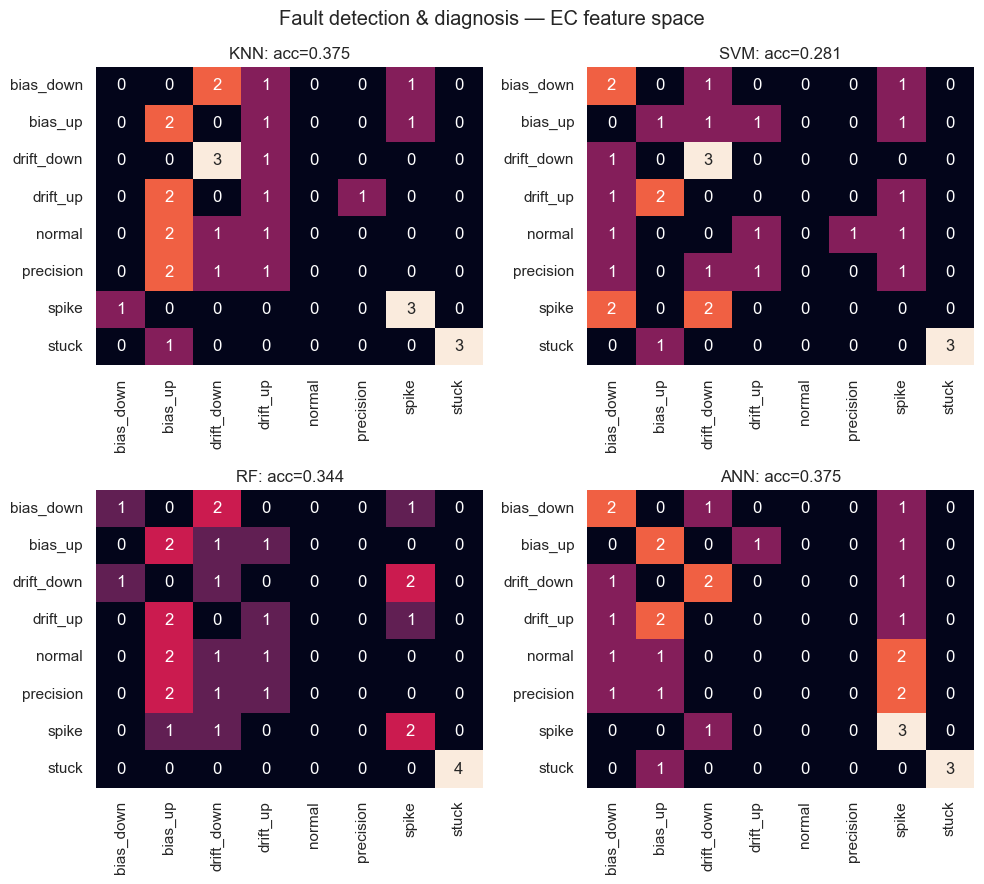

,model,accuracy,macro_f1
0,KNN,0.3750,0.3221
1,SVM,0.2812,0.2426
2,RF,0.3438,0.3091
3,ANN,0.3750,0.3151


In [14]:
clf_models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', C=100, gamma='scale'),
    'RF': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'ANN': MLPClassifier(hidden_layer_sizes=(64,32), max_iter=400, random_state=RANDOM_STATE),
}
fdd_results = []
fig, axes = plt.subplots(2, 2, figsize=(10, 9)); axes = axes.ravel()
for ax, (name, clf) in zip(axes, clf_models.items()):
    clf.fit(X_tr_s, y_tr)
    pred = clf.predict(X_te_s)
    acc = accuracy_score(y_te, pred)
    f1 = f1_score(y_te, pred, average='macro')
    fdd_results.append({'model': name, 'accuracy': acc, 'macro_f1': f1})
    cm = confusion_matrix(y_te, pred, labels=sorted(y_fdd.unique()))
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, xticklabels=sorted(y_fdd.unique()),
                yticklabels=sorted(y_fdd.unique()), cbar=False)
    ax.set_title(f'{name}: acc={acc:.3f}')
plt.suptitle('Fault detection & diagnosis — EC feature space'); plt.tight_layout()
plt.savefig(INN_DIR/'fig_fdd_confusion_matrices.png', dpi=150, bbox_inches='tight'); plt.show()
display(pd.DataFrame(fdd_results).round(4))



## Step 5 — Formal state-space (independent states only)

$$\mathbf{x}_t = [EC_t,\, T_{water,t}]^T, \quad u_t = [pump\_duty,\, T_{air},\, RH]^T$$

TDS is **not** a state variable (algebraic function of EC).


In [15]:
ss = hourly.copy()
ss['ec_next'] = ss['ec'].shift(-1)
ss['wt_next'] = ss['waterTemp'].shift(-1)
ss = ss.dropna()
X_ss = ss[['ec','waterTemp','pump_duty','air_temp','humidity']].values
Y_ss = ss[['ec_next','wt_next']].values
n_tr = int(0.8*len(X_ss))
lr = Ridge(alpha=0.1).fit(X_ss[:n_tr], Y_ss[:n_tr])
Y_hat = lr.predict(X_ss[n_tr:])
ss_m = regression_metrics(Y_ss[n_tr:].ravel(), Y_hat.ravel())
print('State-space 1-step ahead (EC + waterTemp):'); print(pd.Series(ss_m))
coef_df = pd.DataFrame(lr.coef_, columns=['EC','WT','pump','Tair','RH'], index=['dEC','dWT'])
display(coef_df.round(4))


State-space 1-step ahead (EC + waterTemp):
RMSE    174.005419
MAE     103.835596
R2        0.943003
n       118.000000
dtype: float64


,EC,WT,pump,Tair,RH
dEC,0.6465,8.7668,-9.4528,12.3033,5.8680
dWT,-0.0003,0.9089,-0.0591,-0.0422,0.0022


## Step 6 — ML-based decision-making (dosing alert policy)

**Intuition:** Map system state → action. Label: need dosing if EC below setpoint.


In [16]:
EC_SET = hourly['ec'].median()  # data-driven setpoint
pol = hourly.copy()
pol['need_dose'] = (pol['ec'] < EC_SET * 0.92).astype(int)
pol['ec_lag'] = pol['ec'].shift(1); pol['slope'] = pol['ec'].diff(); pol = pol.dropna()
POL_FEATURES = ['ec','waterTemp','pump_duty','pump_phup','air_temp','humidity','oxygen','pressure','ec_lag','slope']
X_p = pol[POL_FEATURES]
y_p = pol['need_dose']
pred_p = np.full(len(y_p), -1)
for tr, te in TimeSeriesSplit(5).split(X_p):
    c = RandomForestClassifier(100, max_depth=8, random_state=RANDOM_STATE)
    c.fit(X_p.iloc[tr], y_p.iloc[tr]); pred_p[te] = c.predict(X_p.iloc[te])
m = pred_p >= 0
print(classification_report(y_p[m], pred_p[m], target_names=['OK','dose']))
policy_acc = accuracy_score(y_p[m], pred_p[m])


              precision    recall  f1-score   support

          OK       0.97      1.00      0.98       161
        dose       1.00      0.94      0.97        79

    accuracy                           0.98       240
   macro avg       0.98      0.97      0.98       240
weighted avg       0.98      0.98      0.98       240



## Step 7 — Predictive control preview (forecast + act)

**Intuition:** MPC philosophy: predict EC one step ahead; trigger action if forecast violates band.


Predictive EC: {'RMSE': 586.4076302126275, 'MAE': 355.1923480336839, 'R2': -0.47476527045103056, 'n': 240}
Would-trigger alerts: 92 / 240 hours


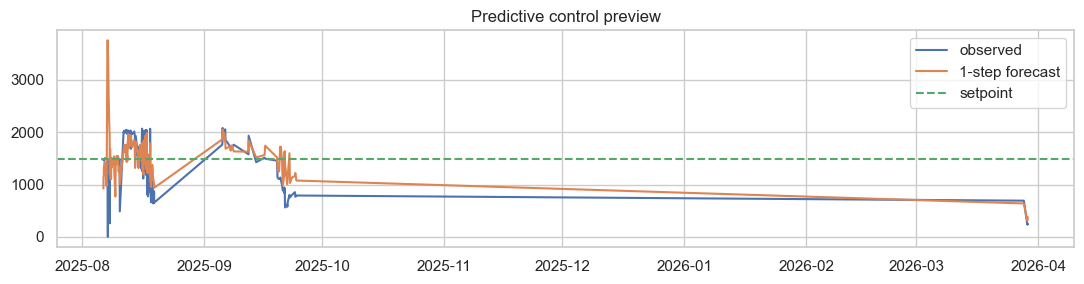

In [17]:
pc = hourly.copy(); pc['ec_next'] = pc['ec'].shift(-1); pc = pc.dropna()
FC_FEATURES = ['ec','waterTemp','pump_duty','air_temp','humidity','oxygen','pressure','light_bh1750']
X_fc = pc[FC_FEATURES]
y_fc = pc['ec_next']
pred_fc = np.full(len(y_fc), np.nan)
for tr, te in TimeSeriesSplit(5).split(X_fc):
    r = Ridge(1.0); r.fit(X_fc.iloc[tr], y_fc.iloc[tr]); pred_fc[te] = r.predict(X_fc.iloc[te])
ok = ~np.isnan(pred_fc)
m_fc = regression_metrics(y_fc[ok], pred_fc[ok])
pc_ok = pc.iloc[ok.nonzero()[0]].copy()
pc_ok['ec_pred'] = pred_fc[ok]
BAND = 0.05
pc_ok['alert'] = (pc_ok['ec_pred'] < EC_SET * (1-BAND)).astype(int)
print('Predictive EC:', m_fc)
print(f'Would-trigger alerts: {pc_ok["alert"].sum()} / {len(pc_ok)} hours')
fig, ax = plt.subplots(figsize=(11,3))
ax.plot(pc_ok['hour'], pc_ok['ec'], label='observed'); ax.plot(pc_ok['hour'], pc_ok['ec_pred'], label='1-step forecast')
ax.axhline(EC_SET, color='g', ls='--', label='setpoint'); ax.legend(); ax.set_title('Predictive control preview')
plt.tight_layout(); plt.savefig(INN_DIR/'fig_predictive_control.png', dpi=150, bbox_inches='tight'); plt.show()


## Step 8 — Real-data anomaly flags from virtual EC residuals

Use **independent** virtual EC (Ridge on `INDEPENDENT_FEATURES`) — large $|residual|$ flags potential sensor faults on field data.


Anomaly hours (|res|>2sigma): 12 / 294


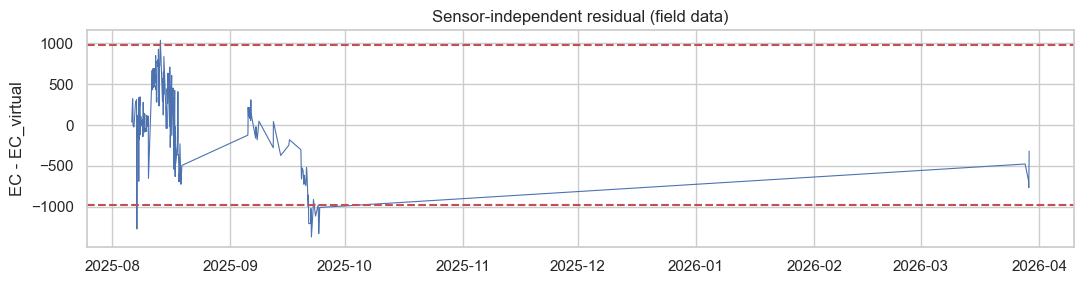

In [18]:
X_v = hourly[INDEPENDENT_FEATURES]; y_v = hourly['ec']
pred_v = np.full(len(y_v), np.nan)
for tr, te in TimeSeriesSplit(5).split(X_v):
    r = Ridge(1.0); r.fit(X_v.iloc[tr], y_v.iloc[tr]); pred_v[te] = r.predict(X_v.iloc[te])
hourly['ec_virtual'] = pred_v
hourly['residual'] = hourly['ec'] - hourly['ec_virtual']
thr = hourly['residual'].std() * 2
hourly['fault_flag'] = (hourly['residual'].abs() > thr).astype(int)
print(f'Anomaly hours (|res|>2sigma): {hourly["fault_flag"].sum()} / {len(hourly)}')
fig, ax = plt.subplots(figsize=(11,3))
ax.plot(hourly['hour'], hourly['residual'], lw=0.8)
ax.axhline(thr, color='r', ls='--'); ax.axhline(-thr, color='r', ls='--')
ax.set(title='Sensor-independent residual (field data)', ylabel='EC - EC_virtual')
plt.tight_layout(); plt.savefig(INN_DIR/'fig_field_residual_fdd.png', dpi=150, bbox_inches='tight'); plt.show()


## Step 9 — Model comparison bar chart (paper Fig. 8a style)


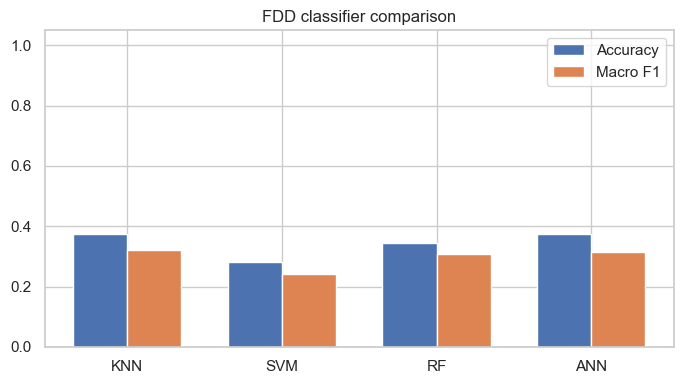

In [19]:
fdd_df = pd.DataFrame(fdd_results)
fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(len(fdd_df)); w = 0.35
ax.bar(x-w/2, fdd_df['accuracy'], w, label='Accuracy')
ax.bar(x+w/2, fdd_df['macro_f1'], w, label='Macro F1')
ax.set_xticks(x); ax.set_xticklabels(fdd_df['model'])
ax.set_ylim(0,1.05); ax.legend(); ax.set_title('FDD classifier comparison')
plt.tight_layout(); plt.savefig(INN_DIR/'fig_fdd_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


## Step 10 — Export & manuscript checklist


In [20]:
innov = pd.DataFrame(fdd_results)
innov['state_space_RMSE'] = ss_m['RMSE']
innov['state_space_R2'] = ss_m['R2']
innov['policy_accuracy'] = policy_acc
innov['predictive_RMSE'] = m_fc['RMSE']
innov.to_csv(DATA_DIR/'results'/'innovation_metrics.csv', index=False)
print('Saved results/innovation_metrics.csv')
print('\nManuscript checklist:')
print('[ ] Table 1 fault models referenced')
print('[ ] FDD confusion matrices (Fig)')
print('[ ] State-space A,B coefficients reported')
print('[ ] ML dosing policy accuracy stated')
print('[ ] Predictive control preview discussed')


Saved results/innovation_metrics.csv

Manuscript checklist:
[ ] Table 1 fault models referenced
[ ] FDD confusion matrices (Fig)
[ ] State-space A,B coefficients reported
[ ] ML dosing policy accuracy stated
[ ] Predictive control preview discussed
